# Phase 3 — AI adoption (postings)

This notebook summarizes AI adoption in postings using demand weights ("tru2").

Outputs are saved under `Results Datasets/analysis/phase3_adoption/`.


In [32]:
from __future__ import annotations

from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Paths
def _find_root():
    if '__file__' in globals():
        return Path(__file__).resolve().parents[2]
    cwd = Path.cwd().resolve()
    for p in [cwd] + list(cwd.parents):
        if (p / 'Results Datasets' / 'final_analysis_dataset.parquet').exists():
            return p
    return cwd

ROOT = _find_root()
DATA_PATH = ROOT / 'Results Datasets' / 'final_analysis_dataset.parquet'
OUT_ROOT = ROOT / 'Results Datasets' / 'analysis' / 'phase3_adoption'
OUT_TABLES = OUT_ROOT / 'tables'
OUT_VIS = OUT_ROOT / 'visuals'
for d in (OUT_ROOT, OUT_TABLES, OUT_VIS):
    d.mkdir(parents=True, exist_ok=True)

# --- Load data
if not DATA_PATH.exists():
    raise FileNotFoundError(DATA_PATH)
df = pd.read_parquet(DATA_PATH)
df = df[(df['adve_time_year'] >= 2010) & (df['adve_time_year'] <= 2024)].copy()

# --- Label helpers (codebook)
def _load_codebook_labels(var_name: str) -> dict[int, str]:
    md_path = ROOT / 'scripts' / 'Analysis' / 'Final dataset field descriptions.md'
    if not md_path.exists():
        return {}
    text = md_path.read_text(encoding='utf-8')
    pat = re.compile(rf"### `{re.escape(var_name)}`(.*?)^### `", re.S | re.M)
    m = pat.search(text)
    if not m:
        return {}
    section = m.group(1)
    label_pat = re.compile(r"- `([^`]+)` =\s*([^\n]+)")
    labels = {}
    for code_raw, label in label_pat.findall(section):
        code_raw = code_raw.strip()
        if code_raw.upper() == 'NA':
            mcode = re.match(r"(-?\d+)\s*(.*)", label.strip())
            if not mcode:
                continue
            code = int(mcode.group(1))
            label_text = mcode.group(2).strip()
        else:
            try:
                code = int(code_raw)
            except ValueError:
                continue
            label_text = label.strip()
            mlabel = re.match(r"\d+\s*(.*)", label_text)
            if mlabel:
                label_text = mlabel.group(1).strip()
        labels[code] = label_text
    return labels

# NUTS-2 / REG2 labels (force map from raw code)
if 'loca_regi_nuts' in df.columns:
    nuts_map = _load_codebook_labels('loca_regi_nuts')
    raw = pd.to_numeric(df['loca_regi_nuts'], errors='coerce')
    df['loca_regi_nuts_label'] = raw.map(nuts_map).fillna('Unknown').astype('string')

if 'loca_labo_reg2' in df.columns:
    reg2_map = _load_codebook_labels('loca_labo_reg2')
    raw = pd.to_numeric(df['loca_labo_reg2'], errors='coerce')
    df['loca_labo_reg2_label'] = raw.map(reg2_map).fillna('Unknown').astype('string')

# Canton labels (force abbreviations)
canton_map = {
    1:'ZH',2:'BE',3:'LU',4:'UR',5:'SZ',6:'OW',7:'NW',8:'GL',9:'ZG',
    10:'FR',11:'SO',12:'BS',13:'BL',14:'SH',15:'AR',16:'AI',17:'SG',
    18:'GR',19:'AG',20:'TG',21:'TI',22:'VD',23:'VS',24:'NE',25:'GE',26:'JU'
}
def _map_canton_label(val):
    if pd.isna(val):
        return 'Unknown'
    s = str(val)
    if s.lower() == 'unknown':
        return 'Unknown'
    if s.isdigit():
        return canton_map.get(int(s), s)
    return s

if 'loca_regi_kant_label' in df.columns:
    df['loca_regi_kant_label'] = df['loca_regi_kant_label'].apply(_map_canton_label).astype('string')
elif 'loca_regi_kant' in df.columns:
    raw = pd.to_numeric(df['loca_regi_kant'], errors='coerce')
    df['loca_regi_kant_label'] = raw.map(canton_map).fillna('Unknown').astype('string')

# Main task labels (from crosswalk CSV if available)
task_label_col = None
task_map_path = ROOT / 'External datasets' / 'Cross-walks' / 'vaca_task_main_labels.csv'
if 'vaca_task_main' in df.columns and task_map_path.exists():
    task_map = pd.read_csv(task_map_path)
    task_map['code'] = pd.to_numeric(task_map['code'], errors='coerce')
    task_map = dict(zip(task_map['code'], task_map['label']))
    task_code = pd.to_numeric(df['vaca_task_main'], errors='coerce')
    df['vaca_task_main_label'] = task_code.map(task_map).fillna('Unknown').astype('string')
    task_label_col = 'vaca_task_main_label'

# --- AI flag
df['ai_requirement'] = df['ai_requirement'].astype('string')
ai_flag = df['ai_requirement'] == 'True'
df_ai = df[ai_flag].copy()

# --- Known AI labels (exclude missing)
df_known = df[df['ai_requirement'].isin(['True','False','Maybe'])].copy()

WEIGHT = 'srvy_wght_tru2'

def _weighted_mean(series, weights):
    s = pd.to_numeric(series, errors='coerce')
    w = pd.to_numeric(weights, errors='coerce')
    mask = s.notna() & w.notna()
    if not mask.any():
        return np.nan
    return np.average(s[mask], weights=w[mask])


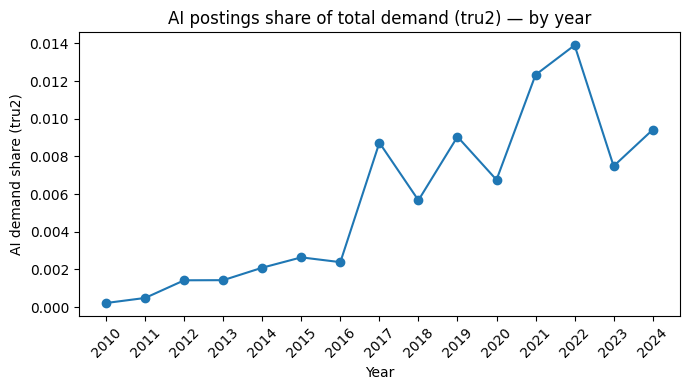

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase3_adoption/visuals/fig_ai_share_by_year.png


In [33]:
# --- AI demand share by year (tru2)
year_tot = df_known.groupby('adve_time_year')[WEIGHT].sum()
year_ai = df_ai.groupby('adve_time_year')[WEIGHT].sum()
year_share = (year_ai / year_tot).fillna(0).reset_index()
year_share = year_share.rename(columns={WEIGHT: 'ai_share_tru2'})
year_share.to_csv(OUT_TABLES / 'table_ai_share_by_year.csv', index=False)

plt.figure(figsize=(7,4))
plt.plot(year_share['adve_time_year'], year_share['ai_share_tru2'], marker='o')
plt.title('AI postings share of total demand (tru2) — by year')
plt.xlabel('Year')
plt.ylabel('AI demand share (tru2)')
plt.xticks(year_share['adve_time_year'], rotation=45)
plt.tight_layout()
fig_path = OUT_VIS / 'fig_ai_share_by_year.png'
plt.savefig(fig_path, dpi=150)
plt.show()
print('Saved', fig_path)


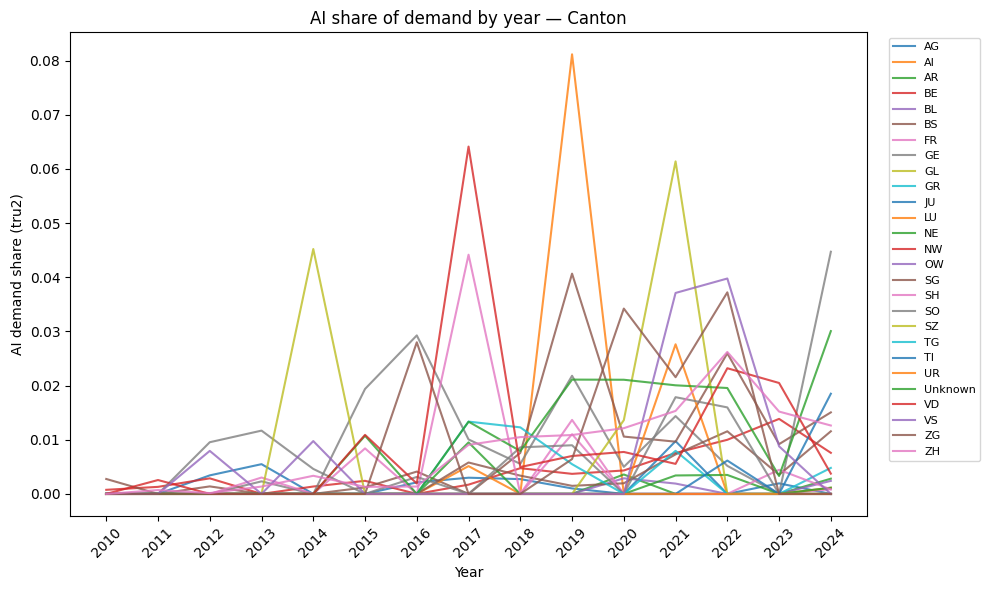

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase3_adoption/visuals/fig_ai_share_by_year_canton.png


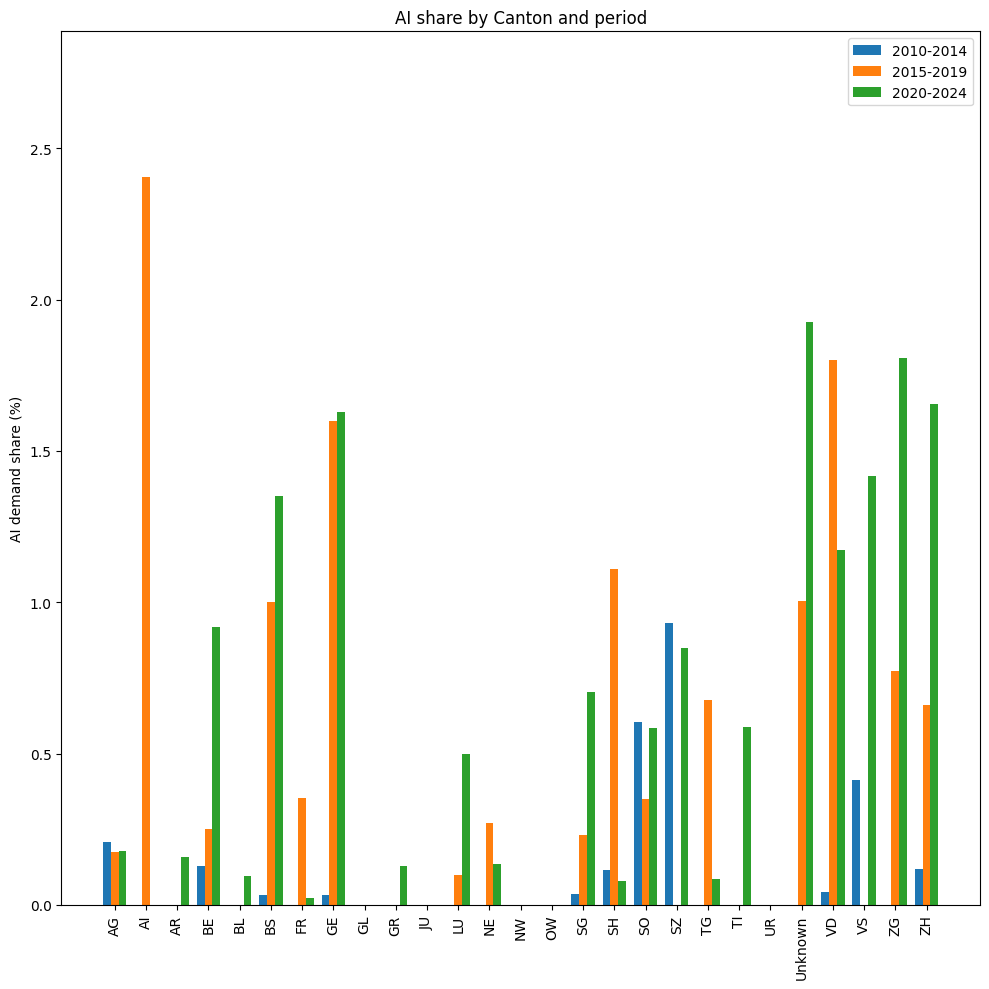

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase3_adoption/visuals/fig_ai_share_by_period_canton.png


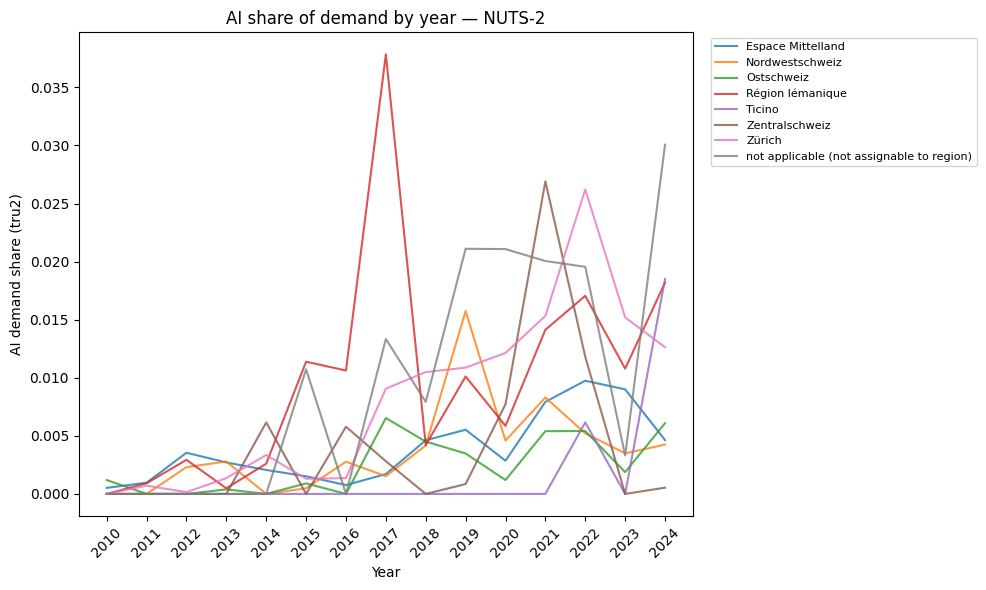

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase3_adoption/visuals/fig_ai_share_by_year_nuts2.png


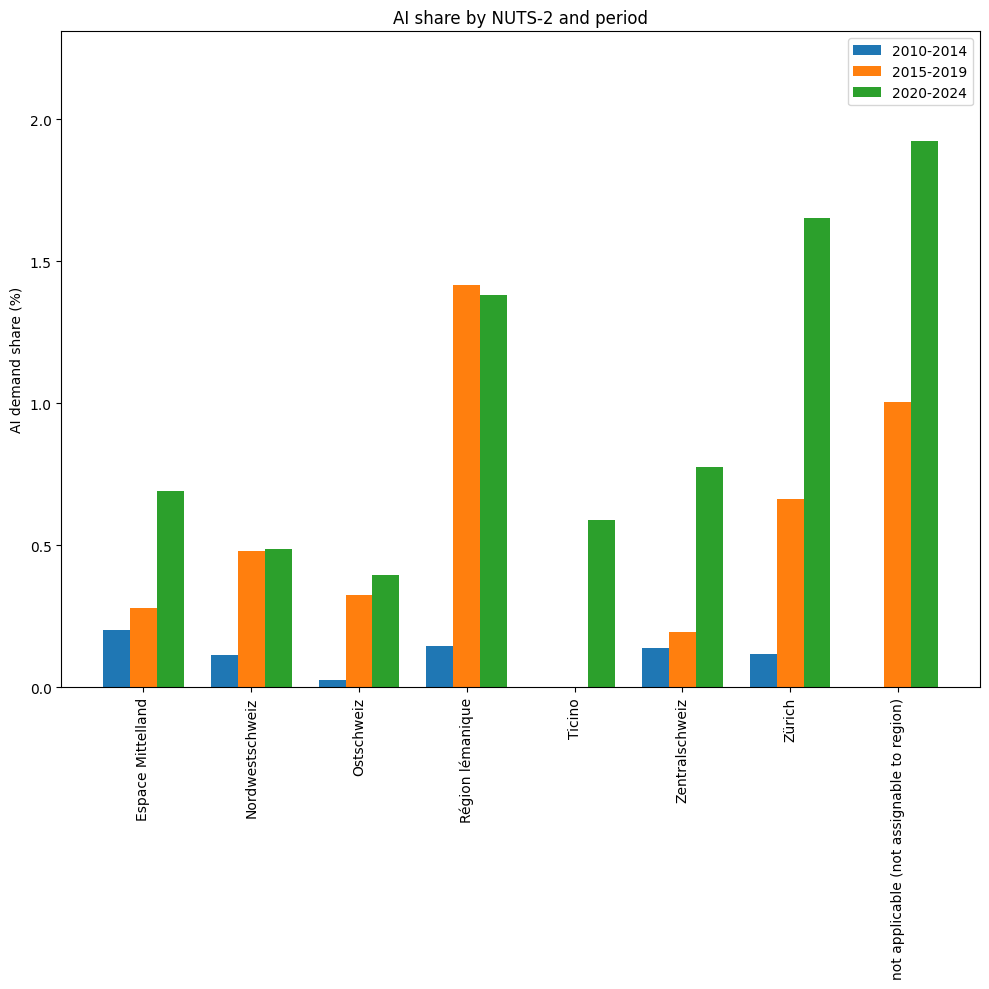

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase3_adoption/visuals/fig_ai_share_by_period_nuts2.png


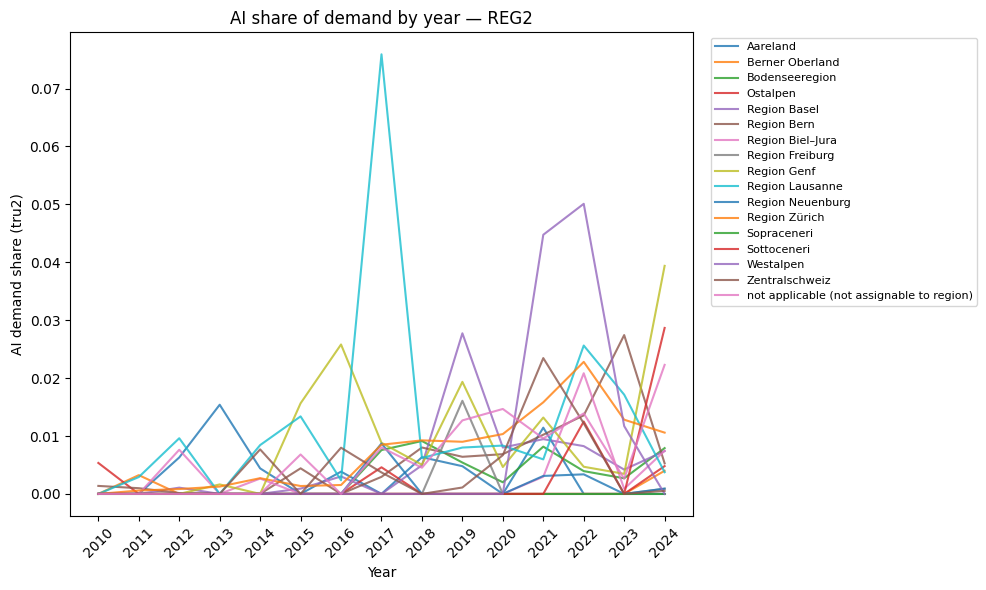

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase3_adoption/visuals/fig_ai_share_by_year_reg2.png


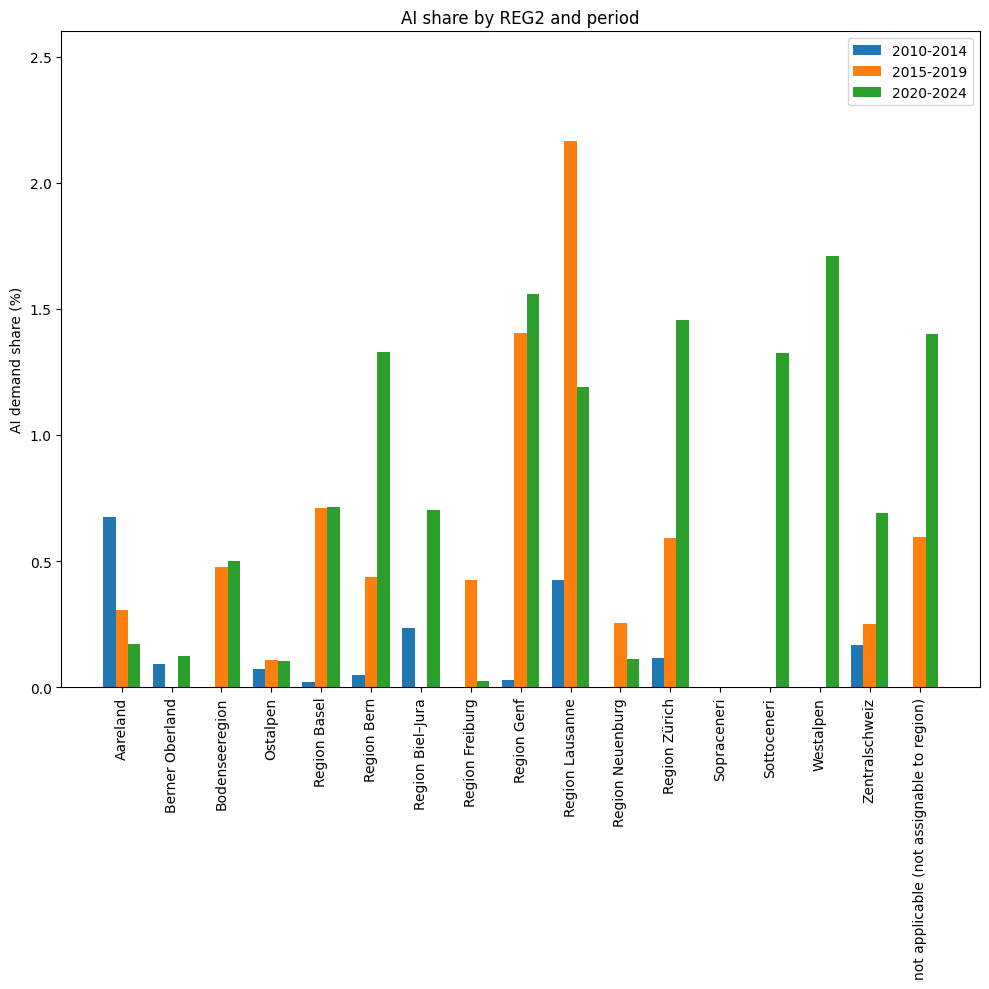

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase3_adoption/visuals/fig_ai_share_by_period_reg2.png


In [34]:
# --- Helper: AI share by year and group (with optional period bars)
PERIODS = [(2010, 2014, '2010-2014'), (2015, 2019, '2015-2019'), (2020, 2024, '2020-2024')]

def _assign_period(series):
    def _lab(y):
        for a,b,lbl in PERIODS:
            if a <= y <= b:
                return lbl
        return 'Other'
    return series.map(_lab)

def _plot_ai_by_year_group(df_ai, df_all, group_col, label, file_tag, period_bar=False):
    ai = (
        df_ai.assign(_g=df_ai[group_col].fillna('Unknown').astype(str))
            .groupby(['adve_time_year', '_g'])[WEIGHT].sum()
            .unstack(fill_value=0)
    )
    tot = (
        df_all.assign(_g=df_all[group_col].fillna('Unknown').astype(str))
             .groupby(['adve_time_year', '_g'])[WEIGHT].sum()
             .unstack(fill_value=0)
    )
    ai = ai.reindex_like(tot).fillna(0)
    share = ai / tot.replace(0, np.nan)
    share = share.fillna(0)

    share.to_csv(OUT_TABLES / f'table_ai_share_by_year_{file_tag}.csv')

    plt.figure(figsize=(10,6))
    for col in share.columns:
        plt.plot(share.index, share[col], label=col, alpha=0.8)
    plt.title(f'AI share of demand by year — {label}')
    plt.xlabel('Year')
    plt.ylabel('AI demand share (tru2)')
    plt.xticks(share.index, rotation=45)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    fig_path = OUT_VIS / f'fig_ai_share_by_year_{file_tag}.png'
    plt.savefig(fig_path, dpi=150)
    plt.show()
    print('Saved', fig_path)

    if period_bar:
        # Period shares by group (bars)
        ai_p = (
            df_ai.assign(_g=df_ai[group_col].fillna('Unknown').astype(str),
                         _p=_assign_period(df_ai['adve_time_year']))
                .groupby(['_g','_p'])[WEIGHT].sum()
                .unstack(fill_value=0)
        )
        tot_p = (
            df_all.assign(_g=df_all[group_col].fillna('Unknown').astype(str),
                         _p=_assign_period(df_all['adve_time_year']))
                .groupby(['_g','_p'])[WEIGHT].sum()
                .unstack(fill_value=0)
        )
        # Align and compute shares
        ai_p = ai_p.reindex_like(tot_p).fillna(0)
        share_p = ai_p / tot_p.replace(0, np.nan)
        share_p = share_p.fillna(0)
        # Keep column order
        order_cols = [lbl for _,_,lbl in PERIODS if lbl in share_p.columns]
        share_p = share_p[order_cols]
        share_p.to_csv(OUT_TABLES / f'table_ai_share_by_period_{file_tag}.csv')

        # Plot as percentage points for visibility
        share_p_pct = share_p * 100
        x = np.arange(len(share_p_pct.index))
        width = 0.25
        plt.figure(figsize=(max(10, len(share_p_pct.index)*0.35), 10))
        for i, col in enumerate(order_cols):
            plt.bar(x + (i-1)*width, share_p_pct[col].values, width=width, label=col)
        plt.xticks(x, share_p_pct.index.astype(str), rotation=90)
        plt.ylabel('AI demand share (%)')
        plt.title(f'AI share by {label} and period')
        max_val = share_p_pct.to_numpy().max()
        if max_val > 0:
            plt.ylim(0, max_val * 1.2)
        plt.legend()
        plt.tight_layout()
        fig_path = OUT_VIS / f'fig_ai_share_by_period_{file_tag}.png'
        plt.savefig(fig_path, dpi=150)
        plt.show()
        print('Saved', fig_path)

# Regions
region_canton = 'loca_regi_kant_label' if 'loca_regi_kant_label' in df_ai.columns else 'loca_regi_kant'
region_nuts = 'loca_regi_nuts_label' if 'loca_regi_nuts_label' in df_ai.columns else ('loca_regi_nuts' if 'loca_regi_nuts' in df_ai.columns else None)
region_reg2 = 'loca_labo_reg2_label' if 'loca_labo_reg2_label' in df_ai.columns else ('loca_labo_reg2' if 'loca_labo_reg2' in df_ai.columns else None)

_plot_ai_by_year_group(df_ai, df_known, region_canton, 'Canton', 'canton', period_bar=True)
if region_nuts:
    _plot_ai_by_year_group(df_ai, df_known, region_nuts, 'NUTS-2', 'nuts2', period_bar=True)
if region_reg2:
    _plot_ai_by_year_group(df_ai, df_known, region_reg2, 'REG2', 'reg2', period_bar=True)


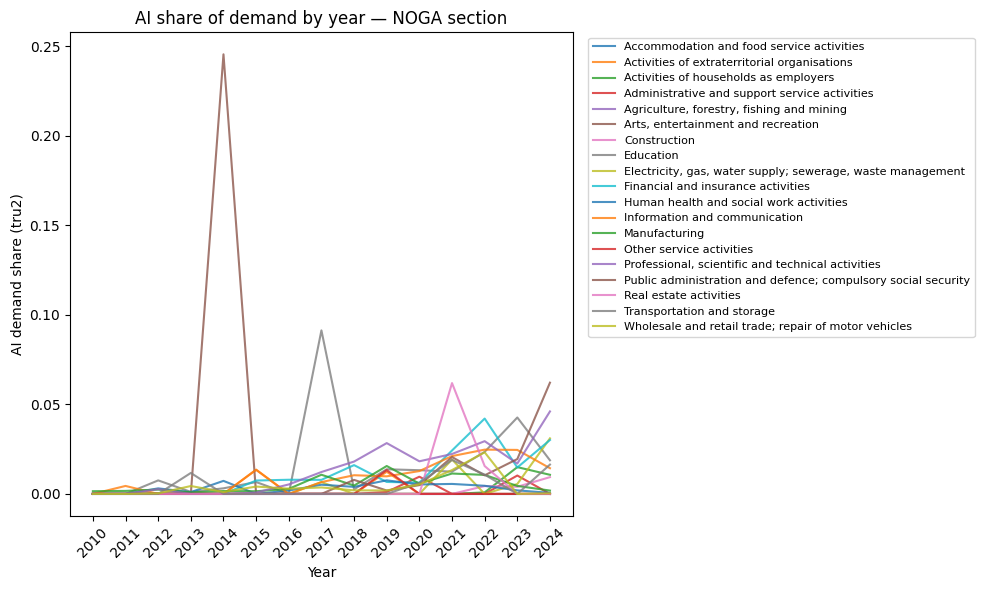

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase3_adoption/visuals/fig_ai_share_by_year_noga_section.png


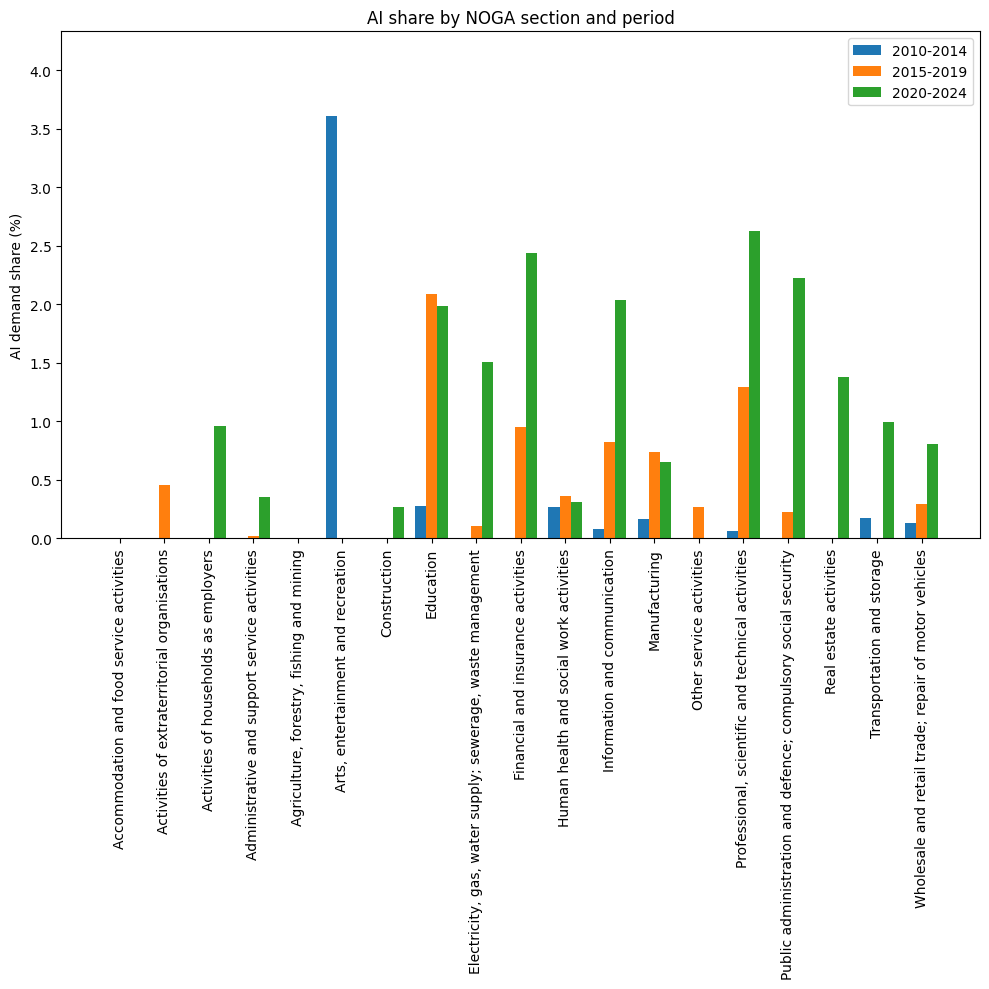

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase3_adoption/visuals/fig_ai_share_by_period_noga_section.png


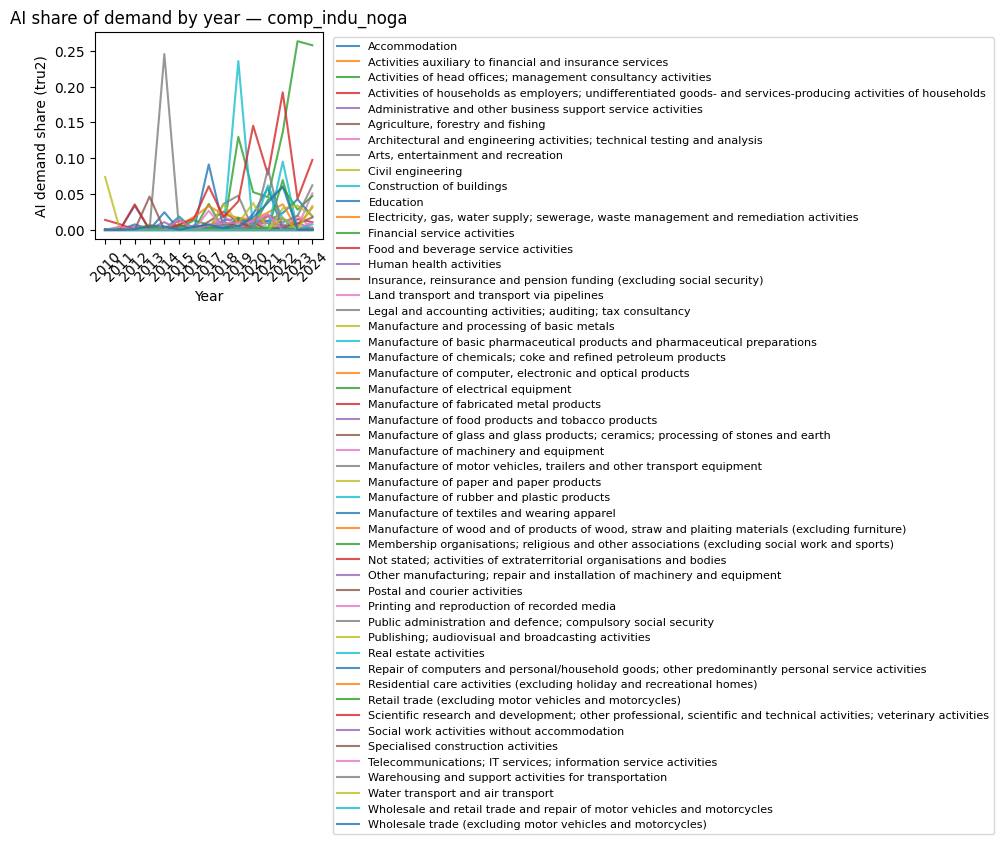

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase3_adoption/visuals/fig_ai_share_by_year_comp_indu_noga.png


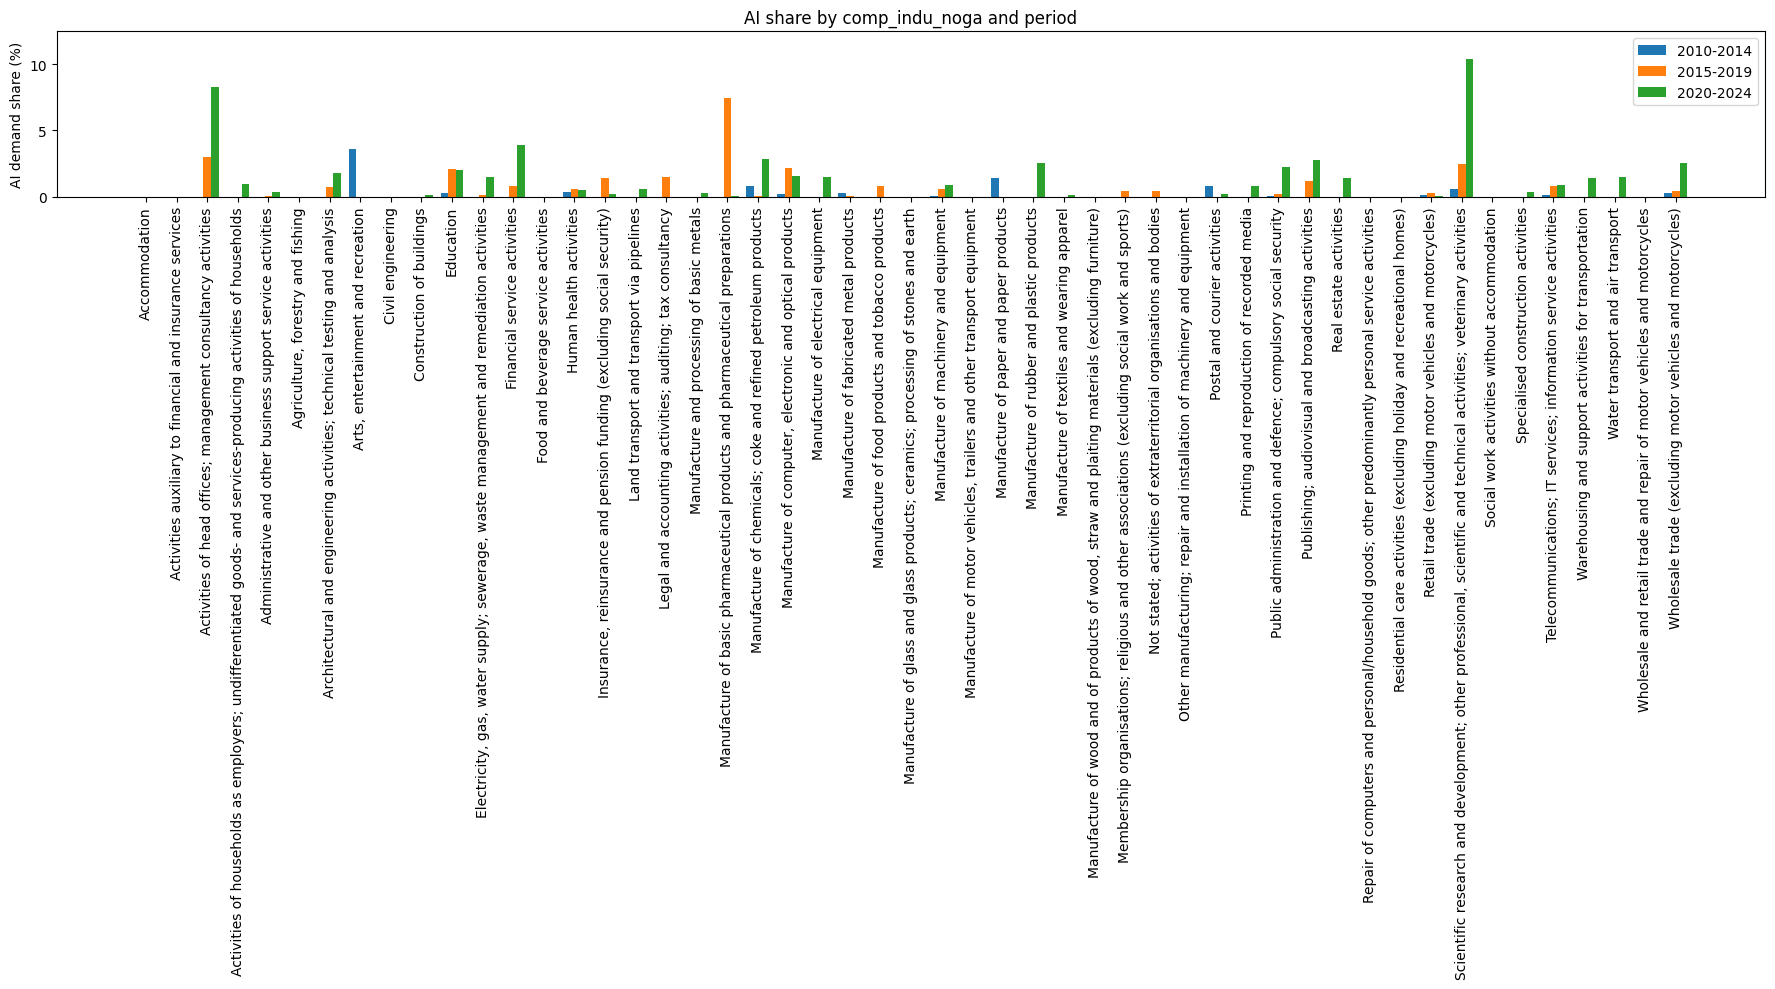

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase3_adoption/visuals/fig_ai_share_by_period_comp_indu_noga.png


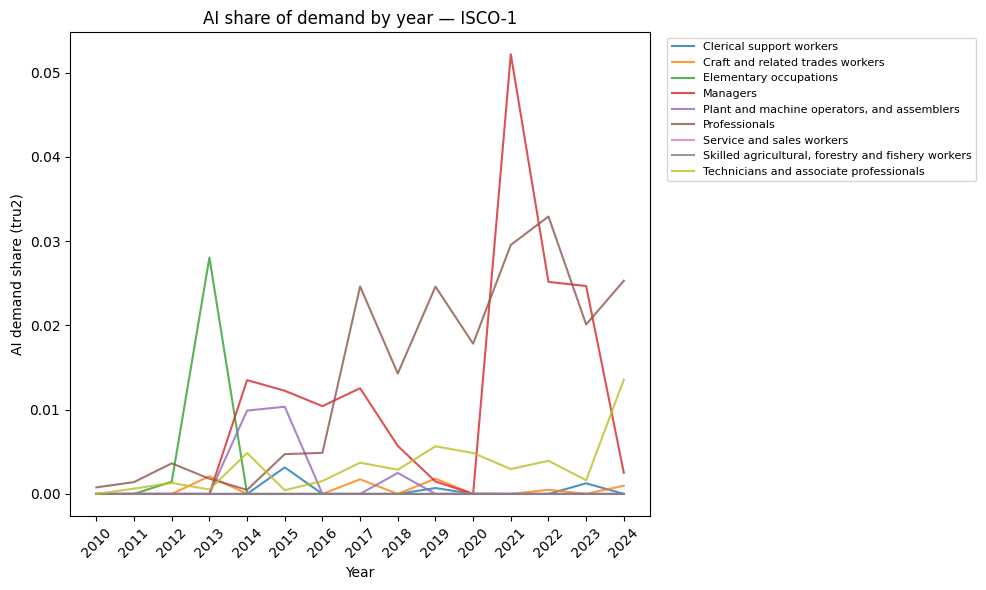

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase3_adoption/visuals/fig_ai_share_by_year_isco1.png


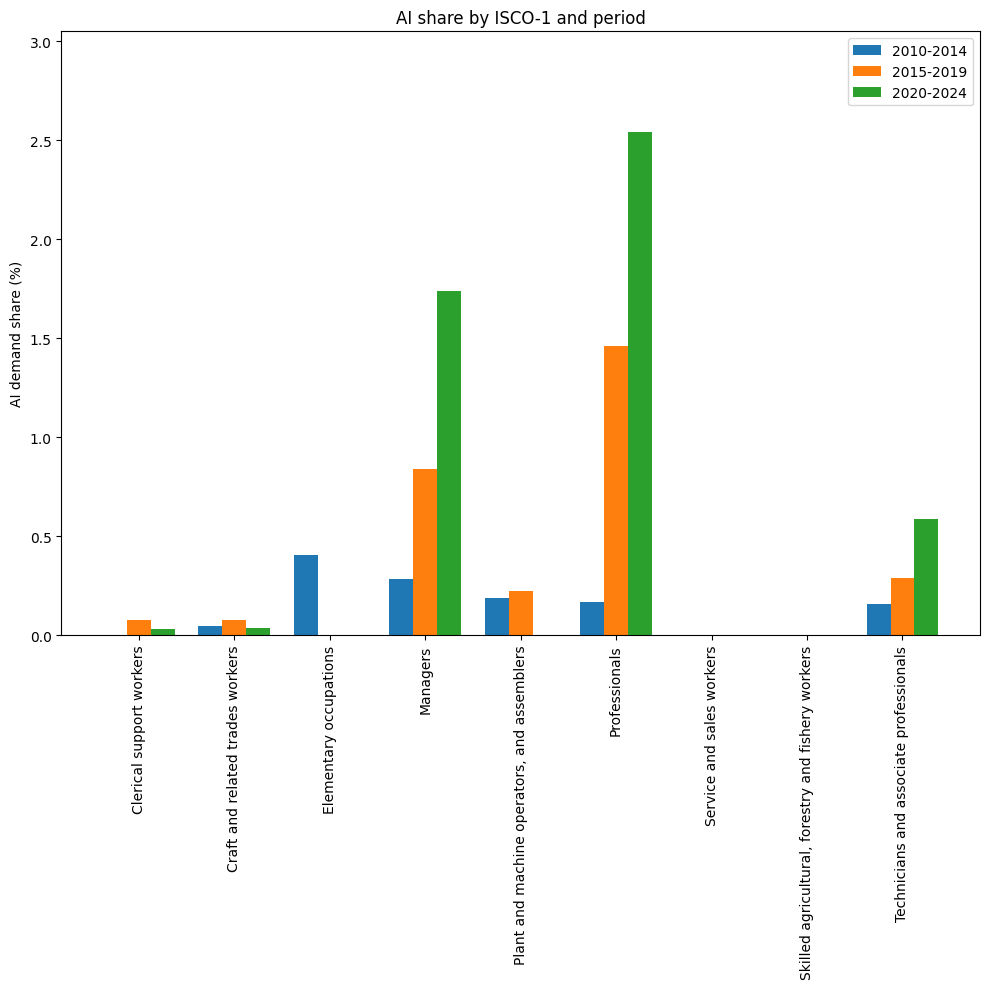

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase3_adoption/visuals/fig_ai_share_by_period_isco1.png


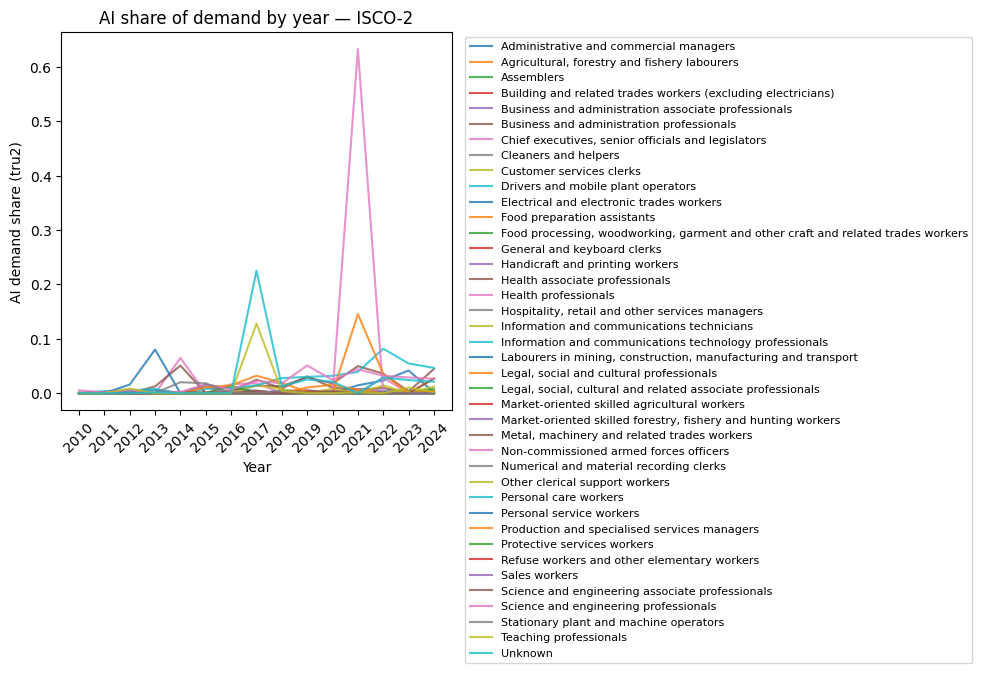

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase3_adoption/visuals/fig_ai_share_by_year_isco2.png


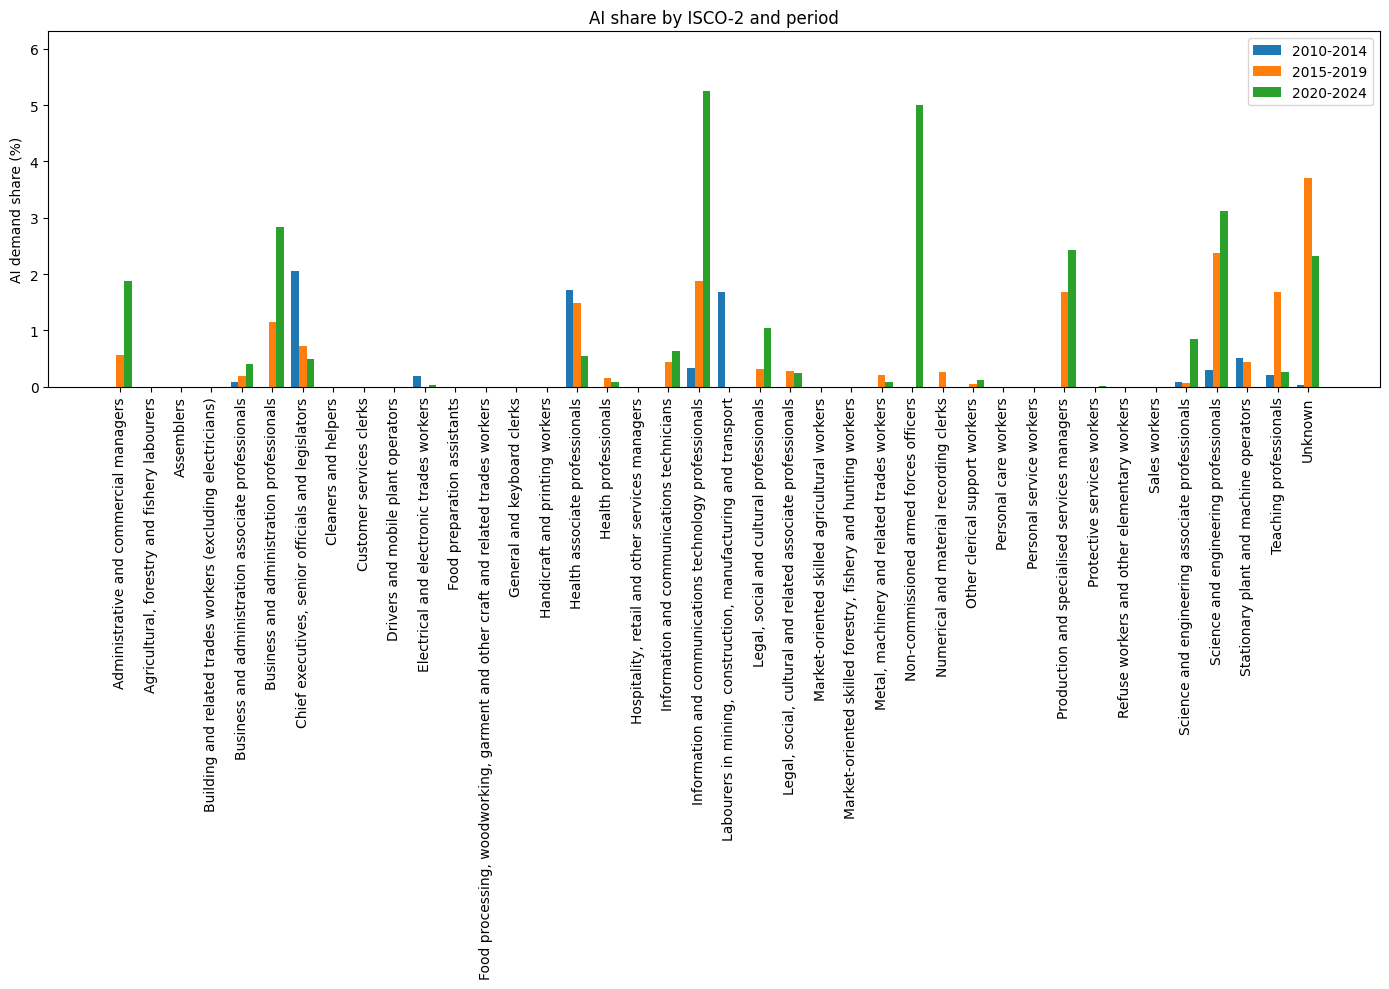

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase3_adoption/visuals/fig_ai_share_by_period_isco2.png


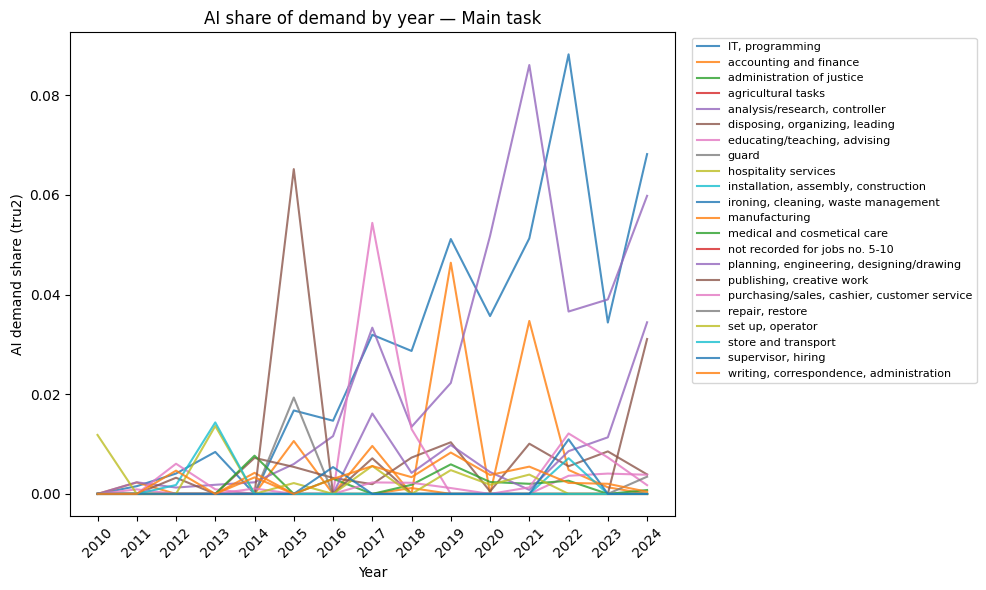

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase3_adoption/visuals/fig_ai_share_by_year_task.png


In [35]:
# --- AI share by year for industry/occupation/task groupings
group_cols = []
if 'industry_section_label' in df_ai.columns:
    group_cols.append(('industry_section_label', 'NOGA section', 'noga_section', True))
elif 'noga_section_label' in df_ai.columns:
    group_cols.append(('noga_section_label', 'NOGA section', 'noga_section', True))
if 'comp_indu_noga_label' in df_ai.columns:
    group_cols.append(('comp_indu_noga_label', 'comp_indu_noga', 'comp_indu_noga', True))
if 'occu_isco1_label' in df_ai.columns:
    group_cols.append(('occu_isco1_label', 'ISCO-1', 'isco1', True))
if 'occu_isco2_label' in df_ai.columns:
    group_cols.append(('occu_isco2_label', 'ISCO-2', 'isco2', True))
if task_label_col:
    group_cols.append((task_label_col, 'Main task', 'task', False))

for col, label, tag, do_period in group_cols:
    _plot_ai_by_year_group(df_ai, df_known, col, label, tag, period_bar=do_period)


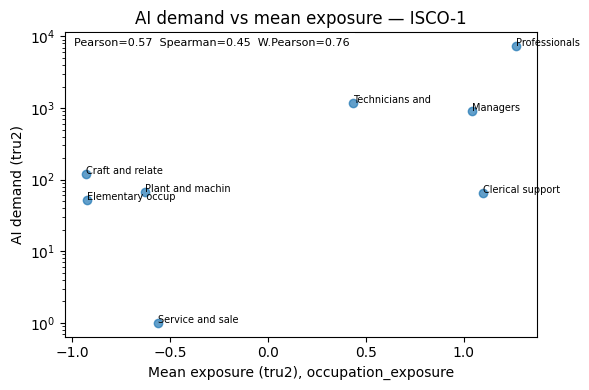

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase3_adoption/visuals/fig_ai_scatter_isco1.png
ISCO-1 Pearson: 0.5720937051460934
ISCO-1 Spearman: 0.4523809523809524
ISCO-1 Weighted Pearson: 0.7618344887841655


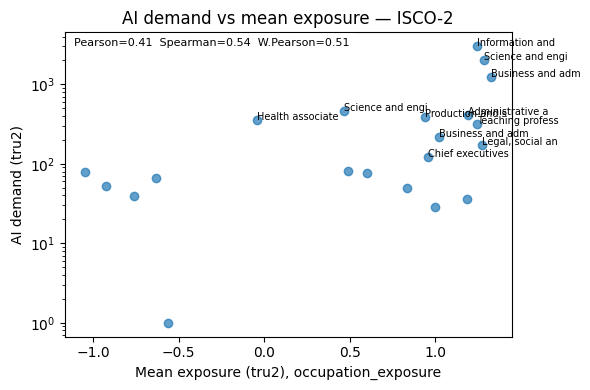

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase3_adoption/visuals/fig_ai_scatter_isco2.png
ISCO-2 Pearson: 0.4074485144344045
ISCO-2 Spearman: 0.5441558441558442
ISCO-2 Weighted Pearson: 0.5135409344710439


posx and posy should be finite values


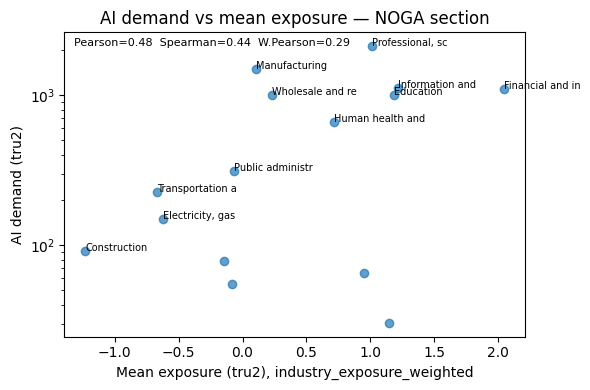

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase3_adoption/visuals/fig_ai_scatter_noga_section.png
NOGA section Pearson: 0.4786654109884182
NOGA section Spearman: 0.4357142857142857
NOGA section Weighted Pearson: 0.28639476344687215


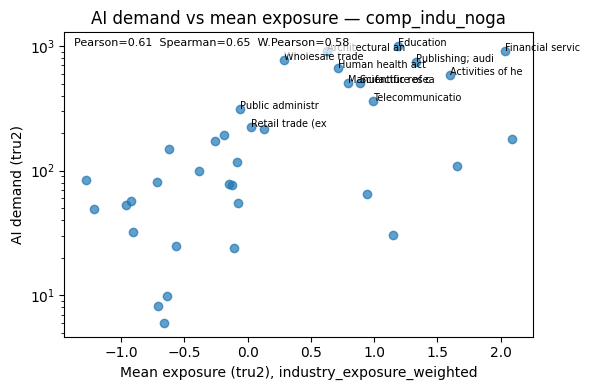

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase3_adoption/visuals/fig_ai_scatter_comp_indu_noga.png
comp_indu_noga Pearson: 0.6097565500316663
comp_indu_noga Spearman: 0.6458172458172459
comp_indu_noga Weighted Pearson: 0.5836639470340462


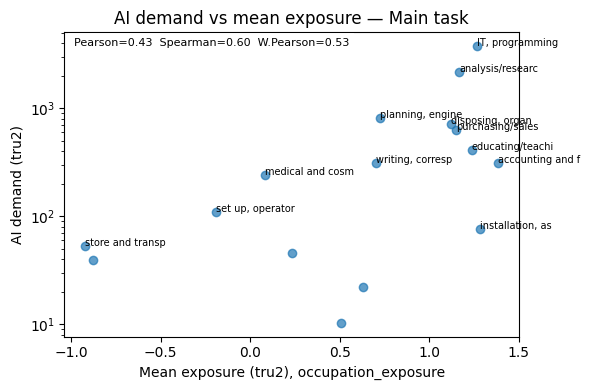

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase3_adoption/visuals/fig_ai_scatter_task.png
Main task Pearson: 0.432826489203996
Main task Spearman: 0.6029411764705882
Main task Weighted Pearson: 0.5321883331105481


In [36]:
# --- Scatter: mean exposure vs AI demand (by group) + correlations
def _scatter_mean_exp_vs_ai_demand(df_ai, group_col, exposure_col, label, file_tag):
    tmp = (
        df_ai.groupby(df_ai[group_col].fillna('Unknown').astype(str))
            .apply(lambda g: pd.Series({
                'ai_demand_tru2': g[WEIGHT].sum(),
                'mean_exposure': _weighted_mean(g[exposure_col], g[WEIGHT]),
            }))
            .reset_index()
            .rename(columns={group_col: 'group'})
    )
    tmp = tmp.replace([np.inf, -np.inf], np.nan)
    tmp = tmp[tmp['ai_demand_tru2'] > 0]
    tmp.to_csv(OUT_TABLES / f'table_ai_scatter_{file_tag}.csv', index=False)

    valid = tmp.dropna(subset=['mean_exposure', 'ai_demand_tru2'])
    pearson = valid[['mean_exposure','ai_demand_tru2']].corr().iloc[0,1] if len(valid) else np.nan
    spearman = valid[['mean_exposure','ai_demand_tru2']].corr(method='spearman').iloc[0,1] if len(valid) else np.nan
    # Weighted Pearson (weights = ai demand)
    w = valid['ai_demand_tru2'].to_numpy(dtype=float)
    x = valid['mean_exposure'].to_numpy(dtype=float)
    y = valid['ai_demand_tru2'].to_numpy(dtype=float)
    if len(valid) and np.isfinite(w).all() and w.sum() > 0:
        wmx = np.average(x, weights=w)
        wmy = np.average(y, weights=w)
        wcov = np.average((x-wmx)*(y-wmy), weights=w)
        wsx = np.sqrt(np.average((x-wmx)**2, weights=w))
        wsy = np.sqrt(np.average((y-wmy)**2, weights=w))
        wpearson = wcov / (wsx*wsy) if wsx>0 and wsy>0 else np.nan
    else:
        wpearson = np.nan

    plt.figure(figsize=(6,4))
    plt.scatter(tmp['mean_exposure'], tmp['ai_demand_tru2'], alpha=0.7)
    # label top 12 by demand
    for _, row in tmp.nlargest(12, 'ai_demand_tru2').iterrows():
        plt.text(row['mean_exposure'], row['ai_demand_tru2'], str(row['group'])[:16], fontsize=7)
    plt.xlabel(f'Mean exposure (tru2), {exposure_col}')
    plt.ylabel('AI demand (tru2)')
    plt.yscale('log')
    plt.title(f'AI demand vs mean exposure — {label}')
    txt = f'Pearson={pearson:.2f}  Spearman={spearman:.2f}  W.Pearson={wpearson:.2f}'
    plt.gca().text(0.02, 0.98, txt, transform=plt.gca().transAxes, va='top', fontsize=8,
               bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    plt.tight_layout()
    fig_path = OUT_VIS / f'fig_ai_scatter_{file_tag}.png'
    plt.savefig(fig_path, dpi=150)
    plt.show()
    print('Saved', fig_path)
    print(f'{label} Pearson:', pearson)
    print(f'{label} Spearman:', spearman)
    print(f'{label} Weighted Pearson:', wpearson)

# ISCO groups -> occupation exposure
if 'occu_isco1_label' in df_ai.columns:
    _scatter_mean_exp_vs_ai_demand(df_ai, 'occu_isco1_label', 'occupation_exposure', 'ISCO-1', 'isco1')
if 'occu_isco2_label' in df_ai.columns:
    _scatter_mean_exp_vs_ai_demand(df_ai, 'occu_isco2_label', 'occupation_exposure', 'ISCO-2', 'isco2')

# NOGA groups -> industry exposure
if 'industry_section_label' in df_ai.columns:
    _scatter_mean_exp_vs_ai_demand(df_ai, 'industry_section_label', 'industry_exposure_weighted', 'NOGA section', 'noga_section')
elif 'noga_section_label' in df_ai.columns:
    _scatter_mean_exp_vs_ai_demand(df_ai, 'noga_section_label', 'industry_exposure_weighted', 'NOGA section', 'noga_section')
if 'comp_indu_noga_label' in df_ai.columns:
    _scatter_mean_exp_vs_ai_demand(df_ai, 'comp_indu_noga_label', 'industry_exposure_weighted', 'comp_indu_noga', 'comp_indu_noga')

# Main task -> occupation exposure
if task_label_col:
    _scatter_mean_exp_vs_ai_demand(df_ai, task_label_col, 'occupation_exposure', 'Main task', 'task')


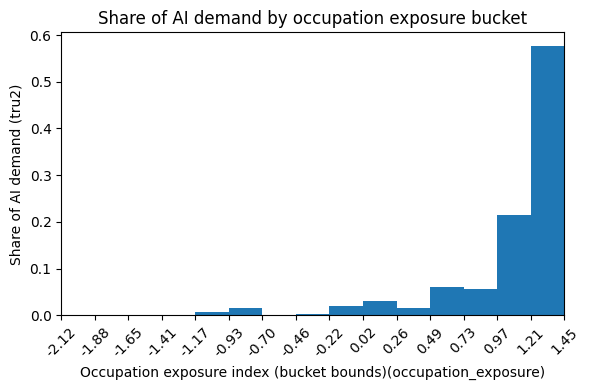

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase3_adoption/visuals/fig_ai_share_by_occ_exposure_bucket_tru2.png


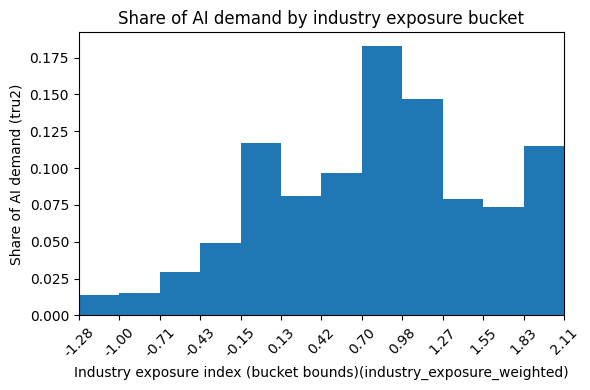

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase3_adoption/visuals/fig_ai_share_by_ind_exposure_bucket_tru2.png


In [43]:
# --- AI demand share by exposure buckets (occupation + industry)
# Use bucket edges from full data for comparability; compute AI demand shares within those buckets.

# Occupation exposure buckets
exposure_col = 'occupation_exposure'
occ_full = df[df[exposure_col].notna()].copy()
if occ_full.empty:
    print('No non-missing occupation exposure values found.')
else:
    num_buckets = 15
    min_exp = occ_full[exposure_col].min()
    max_exp = occ_full[exposure_col].max()
    bucket_edges = np.linspace(min_exp, max_exp, num_buckets + 1)

    ai_occ = df_ai[df_ai[exposure_col].notna()].copy()
    ai_occ['occ_exp_bucket'] = pd.cut(
        ai_occ[exposure_col], bins=bucket_edges, labels=False, include_lowest=True
    )
    ai_bucket = (
        ai_occ.groupby('occ_exp_bucket')
             .agg(demand_tru2=(WEIGHT, 'sum'))
             .reset_index()
    )
    ai_total = ai_bucket['demand_tru2'].sum()
    all_buckets = pd.DataFrame({'occ_exp_bucket': range(len(bucket_edges)-1)})
    ai_bucket_full = all_buckets.merge(ai_bucket, on='occ_exp_bucket', how='left').fillna({'demand_tru2': 0})
    ai_bucket_full['share_of_ai_tru2'] = ai_bucket_full['demand_tru2'] / ai_total if ai_total else 0

    left_edges = bucket_edges[:-1]
    widths = np.diff(bucket_edges)
    plt.figure(figsize=(6,4))
    plt.bar(left_edges, ai_bucket_full['share_of_ai_tru2'], width=widths, align='edge')
    plt.xlabel(f'Occupation exposure index (bucket bounds)({exposure_col})')
    plt.ylabel('Share of AI demand (tru2)')
    plt.title('Share of AI demand by occupation exposure bucket')
    plt.xlim(bucket_edges[0], bucket_edges[-1])
    plt.xticks(bucket_edges, [f'{e:.2f}' for e in bucket_edges], rotation=45)
    plt.tight_layout()
    fig_path = OUT_VIS / 'fig_ai_share_by_occ_exposure_bucket_tru2.png'
    plt.savefig(fig_path, dpi=150)
    plt.show()
    print('Saved', fig_path)

# Industry exposure buckets
ind_col = 'industry_exposure_weighted'
ind_full = df[df[ind_col].notna()].copy()
if ind_full.empty:
    print('No non-missing industry exposure values found.')
else:
    num_buckets_ind = 12
    ind_min = ind_full[ind_col].min()
    ind_max = ind_full[ind_col].max()
    ind_edges = np.linspace(ind_min, ind_max, num_buckets_ind + 1)

    ai_ind = df_ai[df_ai[ind_col].notna()].copy()
    ai_ind['ind_exp_bucket'] = pd.cut(
        ai_ind[ind_col], bins=ind_edges, labels=False, include_lowest=True
    )
    ind_bucket = (
        ai_ind.groupby('ind_exp_bucket')
              .agg(demand_tru2=(WEIGHT, 'sum'))
              .reset_index()
    )
    ind_total = ind_bucket['demand_tru2'].sum()
    all_buckets_ind = pd.DataFrame({'ind_exp_bucket': range(len(ind_edges)-1)})
    ind_bucket_full = all_buckets_ind.merge(ind_bucket, on='ind_exp_bucket', how='left').fillna({'demand_tru2': 0})
    ind_bucket_full['share_of_ai_tru2'] = ind_bucket_full['demand_tru2'] / ind_total if ind_total else 0

    ind_left_edges = ind_edges[:-1]
    ind_widths = np.diff(ind_edges)
    plt.figure(figsize=(6,4))
    plt.bar(ind_left_edges, ind_bucket_full['share_of_ai_tru2'], width=ind_widths, align='edge')
    plt.xlabel(f'Industry exposure index (bucket bounds)({ind_col})')
    plt.ylabel('Share of AI demand (tru2)')
    plt.title('Share of AI demand by industry exposure bucket')
    plt.xlim(ind_edges[0], ind_edges[-1])
    plt.xticks(ind_edges, [f'{e:.2f}' for e in ind_edges], rotation=45)
    plt.tight_layout()
    fig_path = OUT_VIS / 'fig_ai_share_by_ind_exposure_bucket_tru2.png'
    plt.savefig(fig_path, dpi=150)
    plt.show()
    print('Saved', fig_path)


,label,total_demand_tru2,ai_demand_tru2,ai_share,total_share_pct
0,small,368429.3017,351.1858,0.000953,22.511366
1,medium/unknown,792804.7046,3671.6412,0.004631,48.44109
2,large,475402.7891,5696.3058,0.011982,29.047544


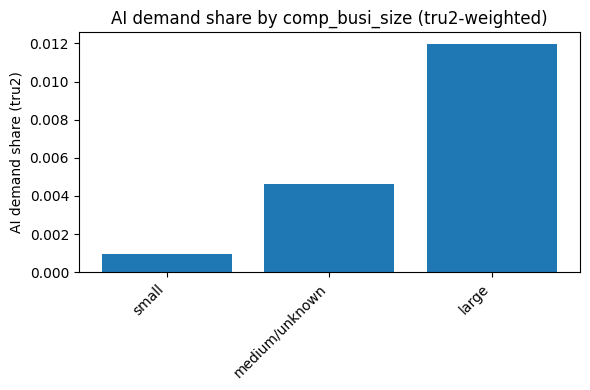

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase3_adoption/visuals/fig_ai_share_by_comp_busi_size.png


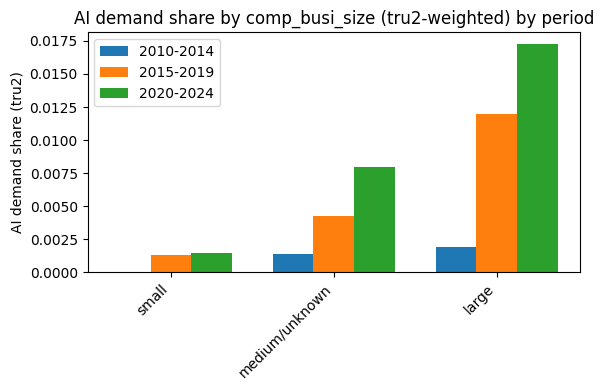

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase3_adoption/visuals/fig_ai_share_by_comp_busi_size_by_period.png


,label,total_demand_tru2,ai_demand_tru2,ai_share,total_share_pct
0,small,368429.3017,351.1858,0.000953,22.511366
1,medium/unknown,792804.7046,3671.6412,0.004631,48.44109
2,large,475402.7891,5696.3058,0.011982,29.047544


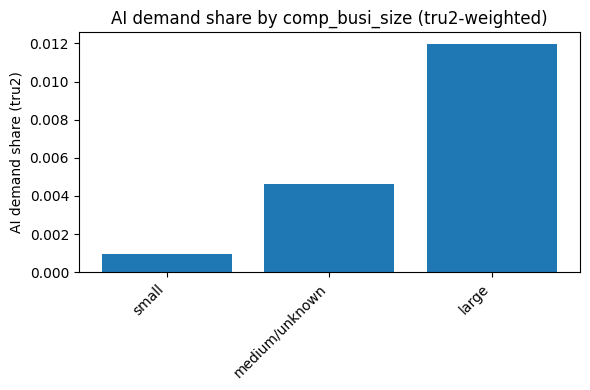

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase3_adoption/visuals/fig_ai_share_by_comp_busi_size.png


,label,total_demand_tru2,ai_demand_tru2,ai_share,total_share_pct
0,no,1434674.3978,7648.4629,0.005331,87.659913
1,yes,201962.3976,2070.6699,0.010253,12.340087


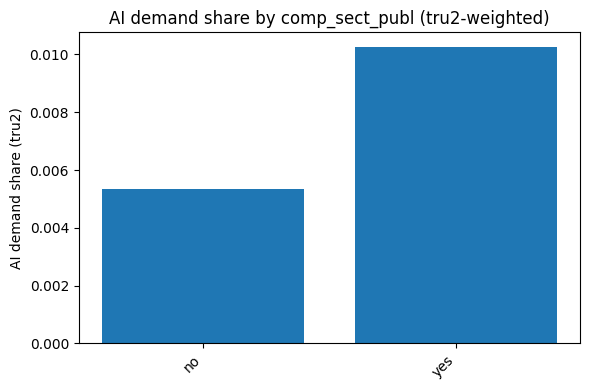

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase3_adoption/visuals/fig_ai_share_by_comp_sect_publ.png


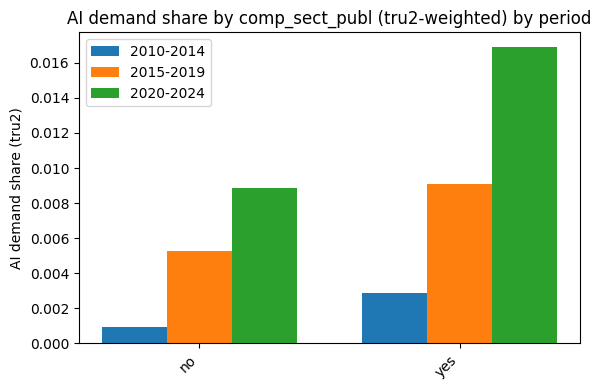

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase3_adoption/visuals/fig_ai_share_by_comp_sect_publ_by_period.png


,label,total_demand_tru2,ai_demand_tru2,ai_share,total_share_pct
0,no,1434674.3978,7648.4629,0.005331,87.659913
1,yes,201962.3976,2070.6699,0.010253,12.340087


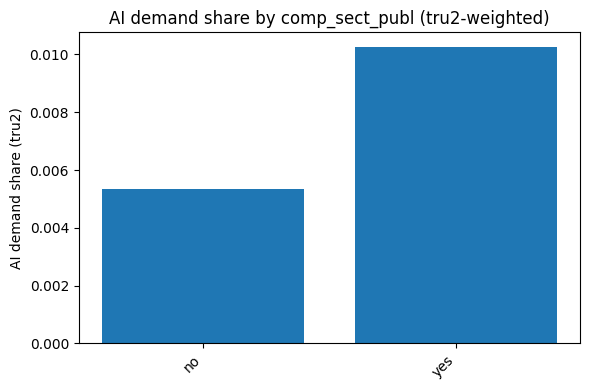

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase3_adoption/visuals/fig_ai_share_by_comp_sect_publ.png


,label,total_demand_tru2,ai_demand_tru2,ai_share,total_share_pct
0,not recorded for jobs no. 5-10,9575.9563,0.0,0.0,0.5851
1,no,1392411.5367,7946.1078,0.005707,85.077614
2,yes,234649.3024,1773.025,0.007556,14.337286


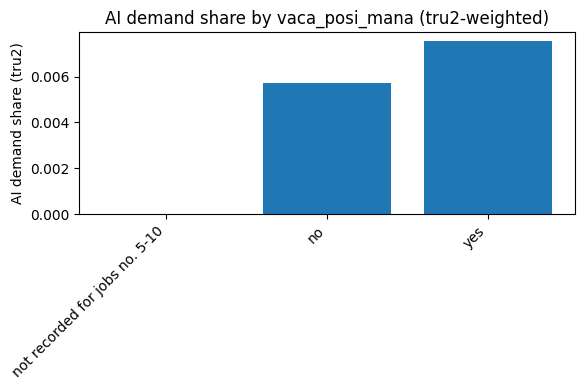

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase3_adoption/visuals/fig_ai_share_by_vaca_posi_mana.png


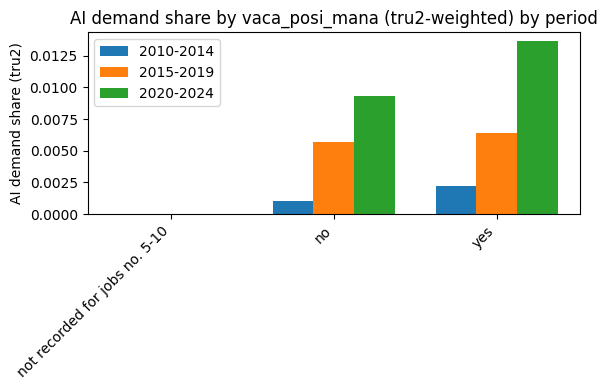

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase3_adoption/visuals/fig_ai_share_by_vaca_posi_mana_by_period.png


,label,total_demand_tru2,ai_demand_tru2,ai_share,total_share_pct
0,not recorded for jobs no. 5-10,9575.9563,0.0,0.0,0.5851
1,no,1392411.5367,7946.1078,0.005707,85.077614
2,yes,234649.3024,1773.025,0.007556,14.337286


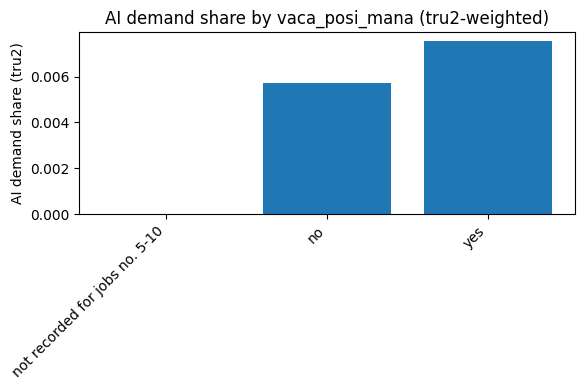

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase3_adoption/visuals/fig_ai_share_by_vaca_posi_mana.png


,label,total_demand_tru2,ai_demand_tru2,ai_share,total_share_pct
0,not recorded for jobs no. 5-10,9575.9563,0.0,0.0,0.5851
1,low/not specified,1469488.5336,8450.3582,0.005751,89.787089
2,medium/high,157572.3055,1268.7746,0.008052,9.627811


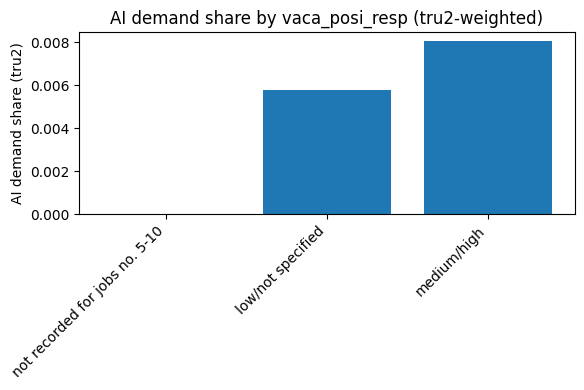

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase3_adoption/visuals/fig_ai_share_by_vaca_posi_resp.png


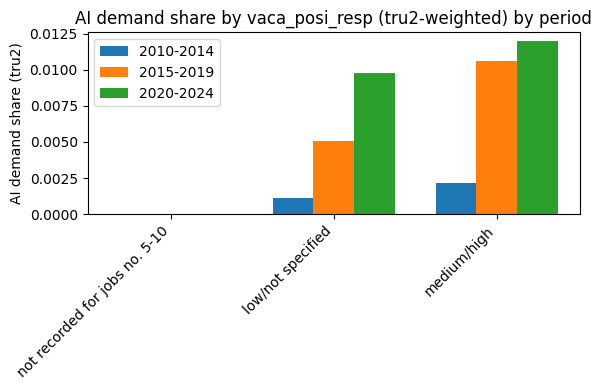

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase3_adoption/visuals/fig_ai_share_by_vaca_posi_resp_by_period.png


,label,total_demand_tru2,ai_demand_tru2,ai_share,total_share_pct
0,not recorded for jobs no. 5-10,9575.9563,0.0,0.0,0.5851
1,low/not specified,1469488.5336,8450.3582,0.005751,89.787089
2,medium/high,157572.3055,1268.7746,0.008052,9.627811


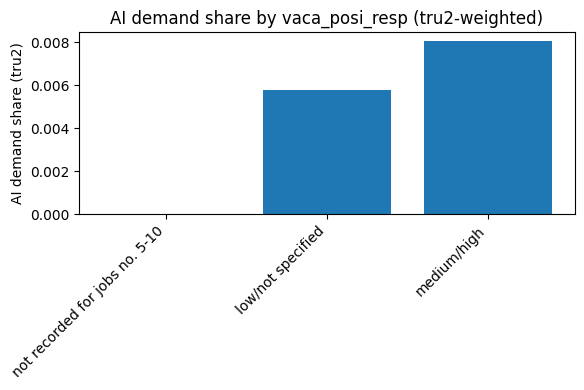

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase3_adoption/visuals/fig_ai_share_by_vaca_posi_resp.png


,label,total_demand_tru2,ai_demand_tru2,ai_share,total_share_pct
0,not recorded for jobs no. 5-10,9575.9563,0.0,0.0,0.5851
1,male,180935.927,237.446,0.001312,11.05535
2,neutral,1400860.6708,9343.5428,0.00667,85.593864
3,female,45264.2413,138.144,0.003052,2.765686


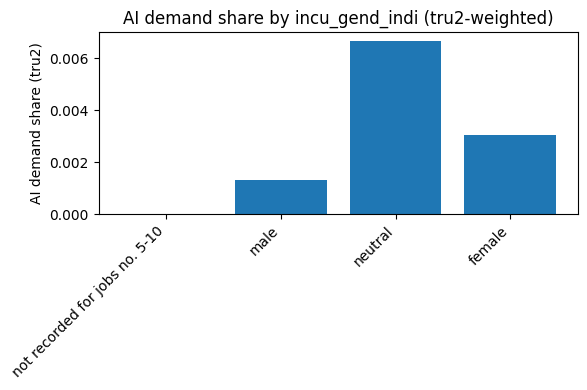

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase3_adoption/visuals/fig_ai_share_by_incu_gend_indi.png


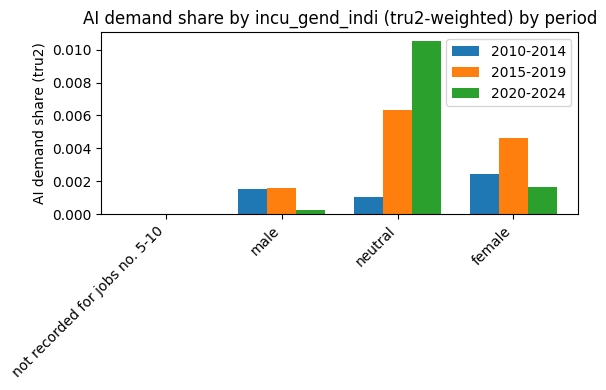

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase3_adoption/visuals/fig_ai_share_by_incu_gend_indi_by_period.png


,label,total_demand_tru2,ai_demand_tru2,ai_share,total_share_pct
0,not recorded for jobs no. 5-10,9575.9563,0.0,0.0,0.5851
1,male,180935.927,237.446,0.001312,11.05535
2,neutral,1400860.6708,9343.5428,0.00667,85.593864
3,female,45264.2413,138.144,0.003052,2.765686


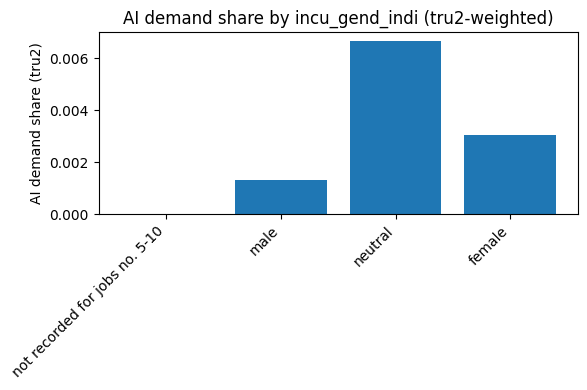

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase3_adoption/visuals/fig_ai_share_by_incu_gend_indi.png


,bin,total_demand_tru2,ai_demand_tru2,ai_share
0,"[11, 16)",16707.5275,0.0,0.0
1,"[16, 22)",63253.2077,52.6978,0.000833
2,"[22, 27)",198694.353,9.1852,0.000046
3,"[27, 32)",196150.0094,137.8077,0.000703
4,"[32, 37)",69157.3473,38.9278,0.000563
5,"[37, 43)",60799.9662,0.0,0.0
6,"[43, 48)",127870.938,171.5659,0.001342
7,"[48, 53)",109577.6146,477.6341,0.004359
8,"[53, 58)",138141.6621,472.0831,0.003417
9,"[58, 64)",94422.9545,170.0454,0.001801


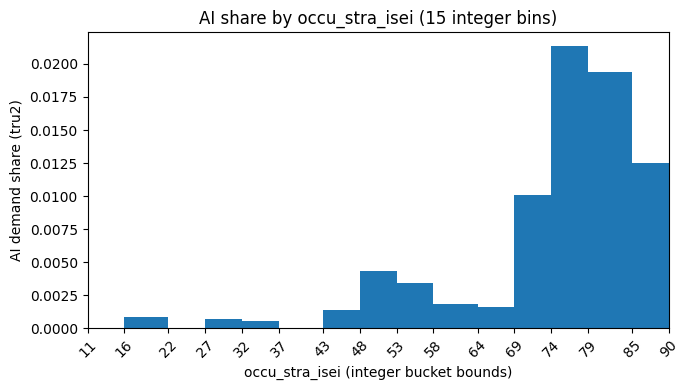

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase3_adoption/visuals/fig_ai_share_by_occu_stra_isei_bins.png


,bin,total_demand_tru2,ai_demand_tru2,ai_share
0,"[13, 17)",5203.5262,0.0,0.0
1,"[17, 22)",56007.9844,52.6978,0.000941
2,"[22, 26)",41151.2339,0.0,0.0
3,"[26, 31)",90248.6936,0.0,0.0
4,"[31, 35)",139828.2438,75.0019,0.000536
5,"[35, 40)",132489.8648,95.6398,0.000722
6,"[40, 44)",231835.8068,84.3303,0.000364
7,"[44, 49)",231174.0503,548.3266,0.002372
8,"[49, 53)",255481.2651,3530.0084,0.013817
9,"[53, 58)",205318.2893,1363.1039,0.006639


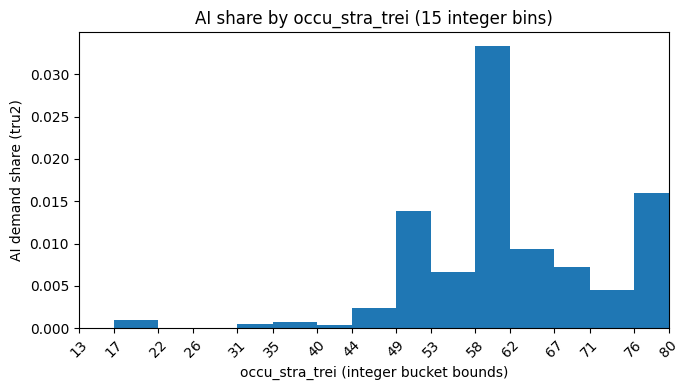

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase3_adoption/visuals/fig_ai_share_by_occu_stra_trei_bins.png


,bin,total_demand_tru2,ai_demand_tru2,ai_share
0,"[0, 1)",210552.0368,343.951,0.001634
1,"[1, 2)",1473.929,0.0,0.0
2,"[2, 3)",22246.7546,4.3333,0.000195
3,"[3, 4)",437646.7864,399.3023,0.000912
4,"[4, 5)",290804.2709,1235.5923,0.004249
5,"[5, 6)",95054.4028,653.4549,0.006875
6,"[6, 7)",164594.4369,2083.4735,0.012658
7,"[7, 8)",108518.2299,1719.5899,0.015846
8,"[8, 9)",115687.0719,2491.1291,0.021533
9,"[9, 10)",16776.5011,398.3312,0.023743


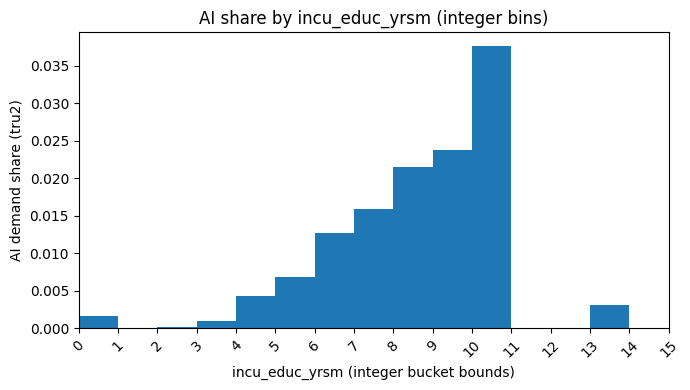

Saved /Users/miguel/Documents/Master Thesis/Thesis/Results Datasets/analysis/phase3_adoption/visuals/fig_ai_share_by_incu_educ_yrsm_bins.png


In [49]:
# --- AI share by other fields (class bars + integer-bin histograms)
# Uses AI share = AI demand (tru2) / total demand (tru2) within each class/bin.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

df_all = df_known.copy()

def _ai_share_by_class(col, title):
    if col not in df_all.columns:
        print(f'Skip {col}: not in dataset')
        return
    all_tmp = df_all[df_all[col].notna()].copy()
    ai_tmp = df_ai[df_ai[col].notna()].copy()
    if all_tmp.empty:
        print(f'Skip {col}: all missing')
        return
    label_map = _load_codebook_labels(col)
    all_tmp['_code'] = pd.to_numeric(all_tmp[col], errors='coerce')
    ai_tmp['_code'] = pd.to_numeric(ai_tmp[col], errors='coerce')
    all_tmp['_label'] = all_tmp['_code'].map(label_map).fillna('Unknown')
    ai_tmp['_label'] = ai_tmp['_code'].map(label_map).fillna('Unknown')

    tot = all_tmp.groupby('_label', observed=True)[WEIGHT].sum().rename('tot')
    ai = ai_tmp.groupby('_label', observed=True)[WEIGHT].sum().rename('ai')
    share = (ai / tot).rename('ai_share').fillna(0)

    table_df = (
        pd.concat([tot, ai, share], axis=1)
        .rename(columns={'tot': 'total_demand_tru2', 'ai': 'ai_demand_tru2'})
        .fillna(0)
        .reset_index()
        .rename(columns={'_label': 'label'})
    )
    total_all = table_df['total_demand_tru2'].sum()
    table_df['total_share_pct'] = (table_df['total_demand_tru2'] / total_all * 100) if total_all else 0

    # order by code if possible
    try:
        label_to_code = {v:k for k,v in label_map.items()}
        order = sorted(share.index, key=lambda x: label_to_code.get(x, 1e9))
        share = share.loc[order]
        table_df = table_df.set_index('label').reindex(order).reset_index()
    except Exception:
        share = share.sort_index()
        table_df = table_df.sort_values('label')

    # small summary table per class
    display(table_df[['label','total_demand_tru2','ai_demand_tru2','ai_share','total_share_pct']])

    x = np.arange(len(share))
    fig_w = max(6, len(share) * 0.5)
    plt.figure(figsize=(fig_w, 4))
    plt.bar(x, share.values)
    plt.xticks(x, share.index, rotation=45, ha='right')
    plt.ylabel('AI demand share (tru2)')
    plt.title(title)
    plt.tight_layout()
    fig_path = OUT_VIS / f'fig_ai_share_by_{col}.png'
    plt.savefig(fig_path, dpi=150)
    plt.show()
    print('Saved', fig_path)

    # Period breakdown plot
    def _period_label(y):
        if 2010 <= y <= 2014:
            return '2010-2014'
        if 2015 <= y <= 2019:
            return '2015-2019'
        if 2020 <= y <= 2024:
            return '2020-2024'
        return None

    all_tmp['_period'] = all_tmp['adve_time_year'].apply(_period_label)
    ai_tmp['_period'] = ai_tmp['adve_time_year'].apply(_period_label)
    period_order = ['2010-2014', '2015-2019', '2020-2024']

    tot_p = all_tmp.groupby(['_label','_period'], observed=True)[WEIGHT].sum().rename('tot')
    ai_p = ai_tmp.groupby(['_label','_period'], observed=True)[WEIGHT].sum().rename('ai')
    share_p = (ai_p / tot_p).rename('ai_share').fillna(0).reset_index()
    pivot = share_p.pivot(index='_label', columns='_period', values='ai_share').fillna(0)

    # align order with overall share plot
    pivot = pivot.reindex(share.index)

    width = 0.25
    fig_w = max(6, len(pivot) * 0.5)
    plt.figure(figsize=(fig_w, 4))
    for i, per in enumerate(period_order):
        vals = pivot[per] if per in pivot.columns else 0
        plt.bar(x + (i-1)*width, vals, width=width, label=per)
    plt.xticks(x, pivot.index, rotation=45, ha='right')
    plt.ylabel('AI demand share (tru2)')
    plt.title(f"{title} by period")
    plt.legend()
    plt.tight_layout()
    fig_path = OUT_VIS / f'fig_ai_share_by_{col}_by_period.png'
    plt.savefig(fig_path, dpi=150)
    plt.show()
    print('Saved', fig_path)


def _integer_edges(min_int, max_int, bins=None):
    if bins is None:
        return np.arange(min_int, max_int + 2)
    edges = np.linspace(min_int, max_int + 1, bins + 1)
    edges = np.unique(np.round(edges).astype(int))
    if len(edges) < 2:
        return np.arange(min_int, max_int + 2)
    return edges


def _ai_share_by_integer_bins(col, title, bins=None):
    if col not in df_all.columns:
        print(f'Skip {col}: not in dataset')
        return
    all_tmp = df_all.copy()
    ai_tmp = df_ai.copy()
    all_tmp[col] = pd.to_numeric(all_tmp[col], errors='coerce')
    ai_tmp[col] = pd.to_numeric(ai_tmp[col], errors='coerce')
    all_tmp = all_tmp[all_tmp[col].notna()]
    ai_tmp = ai_tmp[ai_tmp[col].notna()]
    if all_tmp.empty:
        print(f'Skip {col}: no valid rows')
        return
    min_int = int(np.floor(all_tmp[col].min()))
    max_int = int(np.ceil(all_tmp[col].max()))
    edges = _integer_edges(min_int, max_int, bins=bins)
    all_tmp['bin'] = pd.cut(all_tmp[col], bins=edges, include_lowest=True, right=False)
    ai_tmp['bin'] = pd.cut(ai_tmp[col], bins=edges, include_lowest=True, right=False)

    tot = all_tmp.groupby('bin', observed=True)[WEIGHT].sum().rename('tot')
    ai = ai_tmp.groupby('bin', observed=True)[WEIGHT].sum().rename('ai')
    share = (ai / tot).rename('ai_share').fillna(0)

    table_bins = (
        pd.concat([tot, ai, share], axis=1)
        .rename(columns={'tot': 'total_demand_tru2', 'ai': 'ai_demand_tru2'})
        .reset_index()
    )

    # ensure all bins present
    all_bins = pd.Series(pd.cut(edges[:-1], bins=edges, include_lowest=True, right=False), name='bin')
    share = all_bins.to_frame().merge(share.reset_index(), on='bin', how='left').fillna({'ai_share':0}).set_index('bin')['ai_share']

    # small summary table per bin
    table_bins = all_bins.to_frame().merge(table_bins, on='bin', how='left')
    for c in ['total_demand_tru2','ai_demand_tru2','ai_share']:
        table_bins[c] = table_bins[c].fillna(0)
    display(table_bins[['bin','total_demand_tru2','ai_demand_tru2','ai_share']])

    left_edges = edges[:-1]
    widths = np.diff(edges)
    plt.figure(figsize=(7,4))
    plt.bar(left_edges, share.values, width=widths, align='edge')
    plt.xlabel(f'{col} (integer bucket bounds)')
    plt.ylabel('AI demand share (tru2)')
    plt.title(title)
    plt.xlim(edges[0], edges[-1])
    plt.xticks(edges, rotation=45)
    plt.tight_layout()
    fig_path = OUT_VIS / f'fig_ai_share_by_{col}_bins.png'
    plt.savefig(fig_path, dpi=150)
    plt.show()
    print('Saved', fig_path)


# Bar charts by class (labels only)
for col in ['comp_busi_size', 'comp_sect_publ', 'vaca_posi_mana', 'vaca_posi_resp', 'incu_gend_indi']:
    _ai_share_by_class(col, f'AI demand share by {col} (tru2-weighted)')

# Integer-bucket histograms (AI share)
_ai_share_by_integer_bins('occu_stra_isei', 'AI share by occu_stra_isei (15 integer bins)', bins=15)
_ai_share_by_integer_bins('occu_stra_trei', 'AI share by occu_stra_trei (15 integer bins)', bins=15)
_ai_share_by_integer_bins('incu_educ_yrsm', 'AI share by incu_educ_yrsm (integer bins)', bins=None)
